## 1. Imports 

In [57]:
from typing import Dict, Tuple

from tqdm import tqdm
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchinfo import summary

from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import save_image, make_grid

import matplotlib.pyplot as plt
import pandas as pd

In [6]:
def log_minus_exp(a, b, epsilon=1.e-6):
    return a + torch.log1p(-torch.exp(b - a) + epsilon)

def get_logits_from_logistic_pars(loc, log_scale, num_classes = 10):
    loc = loc.unsqueeze(-1)
    log_scale = log_scale.unsqueeze(-1)

    inv_scale = (-log_scale + 2.0).exp()
    
    bin_width = 2.0 / (num_classes - 1)
    bin_centers = torch.linspace(-1.0, 1.0, num_classes).to(loc.device)
    bin_centers = bin_centers.reshape((*loc.shape, num_classes))
    bin_centers = bin_centers - loc
    log_cdf_min = -torch.log1p((-inv_scale * (bin_centers - 0.5 * bin_width)).exp())
    log_cdf_plus = -torch.log1p((-inv_scale * (bin_centers + 0.5 * bin_width)).exp())
    logits = log_minus_exp(log_cdf_plus, log_cdf_min)
    return logits

loc = torch.randn(1, 1, 1, 1).clip(-1, 1)
log_scale = torch.randn(1, 1, 1, 1)

num_classes = 10
logits = get_logits_from_logistic_pars(loc, log_scale, num_classes)

print(logits[0,0,0,0,:])

tensor([[ -3.5073,  -1.4850,  -0.6512,  -1.6505,  -3.7262,  -6.0187,  -8.3321,
         -10.6145, -12.6102, -13.5910]])


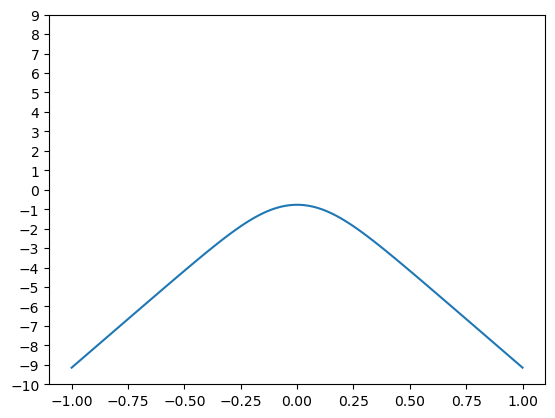

In [7]:
inv_scale = 10
f = lambda x : np.log(1/(1 + np.exp(- inv_scale * (x  + 0.1))) - 1/(1 + np.exp(- inv_scale* (x  - 0.1))))
x = np.linspace(-1, 1, 100)
y = f(x)
plt.plot(x, y)
plt.yticks(np.arange(-10, 10, 1))
plt.show()

In [10]:
beta = 0.1
num_classes = 10
mat = torch.ones(num_classes, num_classes) * beta / num_classes
# diagonal is 1 - (K - 1)/K * beta
mat.diagonal().fill_(1 - (num_classes - 1) * beta / num_classes)
print(mat)

tensor([[0.9100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.9100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.9100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.9100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.9100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.9100, 0.0100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.9100, 0.0100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.9100, 0.0100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.9100,
         0.0100],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.9100]])


## 2. DummyX0Model

In [14]:
blk = lambda ic, oc: nn.Sequential(
    nn.Conv2d(ic, oc, 7, padding=3),
    nn.GroupNorm(oc // 8, oc, affine = False, eps = 1e-4),
    nn.LeakyReLU(),
)

class DummyX0Model(nn.Module):
    """
    This should be unet-like, but let's don't think about the model too much :P
    Basically, any universal R^n -> R^n model should work.
    """

    def __init__(self, n_channel: int, N) -> None:
        super(DummyX0Model, self).__init__()
        self.start =  blk(n_channel, 16)
        self.pe = nn.Parameter(torch.randn(1, 16, 32, 32))
        self.conv = nn.Sequential(
            blk(16, 128),
            blk(128, 256),
            blk(256, 512),
            blk(512, 256),
            blk(256, 128),
            blk(128, 64),
            nn.Conv2d(64, 2 * n_channel, 3, padding=1),
        )
        self.N = N

    def forward(self, x, t) -> torch.Tensor:
        # Lets think about using t later. In the paper, they used Tr-like positional embeddings.
        st = x.float() / self.N - 0.5
        x = self.start(st) + self.pe
        y = self.conv(x)
        loc, log_scale = y.chunk(2, dim=1)

        return torch.tanh(loc + st), log_scale

blk = lambda ic, oc: nn.Sequential(
    nn.Conv2d(ic, oc, 5, padding=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
    nn.Conv2d(oc, oc, 5, padding=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
    nn.Conv2d(oc, oc, 5, padding=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
)

blku = lambda ic, oc: nn.Sequential(
    nn.Conv2d(ic, oc, 5, padding=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
    nn.Conv2d(oc, oc, 5, padding=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
    nn.Conv2d(oc, oc, 5, padding=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
    nn.ConvTranspose2d(oc, oc, 2, stride=2),
    nn.GroupNorm(oc // 8, oc),
    nn.LeakyReLU(),
    
)

class DummyX0Model(nn.Module):
    
    def __init__(self, n_channel: int, N : int = 16) -> None:
        super(DummyX0Model, self).__init__()
        self.down1 = blk(n_channel, 16)
        self.down2 = blk(16, 32)
        self.down3 = blk(32, 64)
        self.down4 = blk(64, 512)
        self.down5 = blk(512, 512)
        self.up1 = blku(512, 512)
        self.up2 = blku(512 + 512, 64)  # Corrected to account for concatenated feature maps
        self.up3 = blku(64 + 64, 32)    # Corrected to account for concatenated feature maps
        self.up4 = blku(32 + 32, 16)    # Corrected to account for concatenated feature maps
        self.convlast = blk(32, 16)
        self.final = nn.Conv2d(16, N * n_channel, 1, bias = False)

        # initialize final with zero
        #self.final.weight.data.zero_()
        #self.final.bias.data.zero_()

        self.tr1 = nn.TransformerEncoderLayer(d_model=512, nhead=8)
        self.tr2 = nn.TransformerEncoderLayer(d_model=512, nhead=8)
        self.tr3 = nn.TransformerEncoderLayer(d_model=64, nhead=8)

        self.temb_1 = nn.Linear(32, 16)
        self.temb_2 = nn.Linear(32, 32)
        self.temb_3 = nn.Linear(32, 64)
        self.temb_4 = nn.Linear(32, 512)
        self.N = N

    def forward(self, x, t) -> torch.Tensor:
        x = (2 * x.float() / self.N) - 1.0
        t = t.float().reshape(-1, 1) / 500
        t_as_sin = [torch.sin(t * 3.1415 * 2 ** i) for i in range(16)]
        t_as_cos = [torch.cos(t * 3.1415 * 2 ** i) for i in range(16)]
        # concat and send it to t_emb
        t_emb_1 = self.temb_1(torch.cat(t_as_sin + t_as_cos, dim=1).to(x.device)).reshape(x.shape[0], -1, 1, 1)
        t_emb_2 = self.temb_2(torch.cat(t_as_sin + t_as_cos, dim=1).to(x.device)).reshape(x.shape[0], -1, 1, 1)
        t_emb_3 = self.temb_3(torch.cat(t_as_sin + t_as_cos, dim=1).to(x.device)).reshape(x.shape[0], -1, 1, 1)
        t_emb_4 = self.temb_4(torch.cat(t_as_sin + t_as_cos, dim=1).to(x.device)).reshape(x.shape[0], -1, 1, 1)
        
        x1 = self.down1(x) + t_emb_1
        x2 = self.down2(nn.functional.avg_pool2d(x1, 2)) + t_emb_2
        x3 = self.down3(nn.functional.avg_pool2d(x2, 2)) + t_emb_3
        x4 = self.down4(nn.functional.avg_pool2d(x3, 2)) + t_emb_4
        x5 = self.down5(nn.functional.avg_pool2d(x4, 2))

        x5 = self.tr1(x5.reshape(x5.shape[0], x5.shape[1], -1).transpose(1, 2)).transpose(1, 2).reshape(x5.shape)

        y = self.up1(x5)

        y = self.tr2(y.reshape(y.shape[0], y.shape[1], -1).transpose(1, 2)).transpose(1, 2).reshape(y.shape)
  
        y = self.up2(torch.cat([x4, y], dim=1))

        y = self.tr3(y.reshape(y.shape[0], y.shape[1], -1).transpose(1, 2)).transpose(1, 2).reshape(y.shape)

        y = self.up3(torch.cat([x3, y], dim=1))

        y = self.up4(torch.cat([x2, y], dim=1))


        y = self.convlast(torch.cat([x1, y], dim=1))
        y = self.final(y)
        # reshape to B, C, H, W, N
        y = y.reshape(y.shape[0], -1, self.N, *x.shape[2:]).transpose(2, -1).contiguous()
      
        return y

In [15]:
def get_logits_from_logistic_pars(loc, log_scale, num_classes = 10):
    loc = loc.unsqueeze(-1)
    log_scale = log_scale.unsqueeze(-1)
    inv_scale = (-log_scale + 2.0).exp()

    bin_width = 2.0 / (num_classes - 1)
    bin_centers = torch.linspace(-1.0, 1.0, num_classes).to(loc.device)
    bin_centers = bin_centers.reshape([1] * (len(loc.shape) - 1) + [num_classes])
    bin_centers = bin_centers - loc
    log_cdf_min = -torch.log1p((-inv_scale * (bin_centers - 0.5 * bin_width)).exp())
    log_cdf_plus = -torch.log1p((-inv_scale * (bin_centers + 0.5 * bin_width)).exp())
    logits = log_minus_exp(log_cdf_plus, log_cdf_min)
    return logits

In [22]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            _ = torch.zeros(1, device="mps")
            return torch.device("mps")
        except Exception:
            pass
    return torch.device("cpu")

device = get_device()
print("Using device:", device)

Using device: cuda


In [27]:
# check if it takes 2, 1, 28, 28 input
model = DummyX0Model(1, N = 16)
x = torch.randn(2, 1, 32, 32)
t = torch.tensor([1, 2])
print(model(x, t).shape)
summary(model, input_data=(x, t))

torch.Size([2, 1, 32, 32, 16])


Layer (type:depth-idx)                   Output Shape              Param #
DummyX0Model                             [2, 1, 32, 32, 16]        --
├─Linear: 1-1                            [2, 16]                   528
├─Linear: 1-2                            [2, 32]                   1,056
├─Linear: 1-3                            [2, 64]                   2,112
├─Linear: 1-4                            [2, 512]                  16,896
├─Sequential: 1-5                        [2, 16, 32, 32]           --
│    └─Conv2d: 2-1                       [2, 16, 32, 32]           416
│    └─GroupNorm: 2-2                    [2, 16, 32, 32]           32
│    └─LeakyReLU: 2-3                    [2, 16, 32, 32]           --
│    └─Conv2d: 2-4                       [2, 16, 32, 32]           6,416
│    └─GroupNorm: 2-5                    [2, 16, 32, 32]           32
│    └─LeakyReLU: 2-6                    [2, 16, 32, 32]           --
│    └─Conv2d: 2-7                       [2, 16, 32, 32]           6,4

## 3. D3PM model

In [45]:
def log_minus_exp(a, b, epsilon=1e-6):
    return a + torch.log1p(-torch.exp(b - a) + epsilon)

In [46]:
class D3PM(nn.Module):
    def __init__(
        self,
        x0_model: nn.Module,
        n_T: int,
        num_classes: int = 10,
        forward_type = 'uniform',
        hybrid_loss_coeff = 0.001
    ) -> None:
        super(D3PM, self).__init__()
        self.x0_model = x0_model

        self.n_T = n_T
        self.hybrid_loss_coeff = hybrid_loss_coeff
        self.beta_t = [1 / (self.n_T - t + 1) for t in range(1, self.n_T + 1)]
        self.eps = 1e-8
        self.num_classses = num_classes
        q_onestep_mats = []
        q_mats = [] # these are cumulative

        for beta in self.beta_t:

            if forward_type == 'uniform':
                mat = torch.ones(num_classes, num_classes) * beta / num_classes
                mat.diagonal().fill_(1 - (num_classes - 1) * beta / num_classes)
                q_onestep_mats.append(mat)
            else:
                raise NotImplementedError
        q_one_step_mats = torch.stack(q_onestep_mats, dim=0)

        q_one_step_transposed = q_one_step_mats.transpose(1, 2) # this will be used for q_posterior_logits

        q_mat_t = q_onestep_mats[0]
        q_mats = [q_mat_t]
        for idx in range(1, self.n_T):
            q_mat_t = q_mat_t @ q_onestep_mats[idx]
            q_mats.append(q_mat_t)
        q_mats = torch.stack(q_mats, dim=0)
        self.logit_type = 'logit'

        # register
        self.register_buffer("q_one_step_transposed", q_one_step_transposed)
        self.register_buffer("q_mats", q_mats)

        assert self.q_mats.shape == (self.n_T, num_classes, num_classes), self.q_mats.shape
    
    def _at(self, a, t, x):
        # t is 1-d, x is integer value of 0 to num_classes - 1
        bs = t.shape[0]
        t = t.reshape((bs, *[1] * (x.dim() - 1)))
        #out[i, j, k, l, m] = a[t[i, j, k, l], x[i, j, k, l], m]
        return a[t - 1, x, :]


    def q_posterior_logits(self, x_0, x_t, t):
        # if t == 1, this means we return the L_0 loss, so directly try to x_0 logits.
        # otherwise, we return the L_{t-1} loss.
        # Also, we never have t == 0.

        # if x_0 is integer, we convert it to one-hot.
        if x_0.dtype == torch.int64 or x_0.dtype == torch.int32:
            x_0_logits = torch.log(torch.nn.functional.one_hot(x_0, self.num_classses) + self.eps)
        else:
            x_0_logits = x_0.clone()

        assert x_0_logits.shape == x_t.shape + (self.num_classses,), print(f"x_0_logits.shape: {x_0_logits.shape}, x_t.shape: {x_t.shape}")

        # Here, we caclulate equation (3) of the paper. Note that the x_0 Q_t x_t^T is a normalizing constant, so we don't deal with that.
        # fact1 is "guess of x_{t-1}" from x_t
        # fact2 is "guess of x_{t-1}" from x_0

        fact1 = self._at(self.q_one_step_transposed, t, x_t)
        #fact2 = self._at_onehot(self.q_mats, t-1, )
        # x, a[t-1]


        softmaxed = torch.softmax(x_0_logits, dim=-1) # bs, ..., num_classes
        qmats2 = self.q_mats[t-2] # bs, num_classes, num_classes

        fact2 = torch.einsum('b...c,bcd->b...d', softmaxed, qmats2)
    
        #print(f"Fact1Fact2", fact1.shape, fact2.shape)
        out = torch.log(fact1 + self.eps) + torch.log(fact2 + self.eps)
        #print(f"out: {out.shape}")
        t_broadcast = t.reshape((t.shape[0], *[1] * (x_t.dim())))
        #print(t_broadcast.shape)
        bc = torch.where(t_broadcast == 1, x_0_logits, out)
        #print(f"bc: {bc.shape}")
        return bc

    def vb(self, dist1, dist2):
        out = (torch.softmax(dist1 + self.eps, dim = -1)*(torch.log_softmax(dist1 + self.eps, dim = -1) - torch.log_softmax(dist2 + self.eps, dim = -1)))
        return out.sum(dim=-1).mean()

        
    def q_sample(self, x_0, t, noise):
        # forward process, x_0 is the clean input.
        
        logits = torch.log(self._at(self.q_mats, t, x_0) + self.eps)
        noise = torch.clip(noise, self.eps, 1.0)
        gumbel_noise = -torch.log(-torch.log(noise))
        return torch.argmax(logits + gumbel_noise, dim=-1)

    def model_predict(self, x_0, t):
        if self.logit_type == 'logit':
            predicted_x0_logits = self.x0_model(x_0, t)
        else:
            loc, log_scale = self.x0_model(x_0, t)
            predicted_x0_logits = get_logits_from_logistic_pars(loc, log_scale, self.num_classses)
        return predicted_x0_logits

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Makes forward diffusion x_t from x_0, and tries to guess x_0 value from x_t using x0_model.
        x is one-hot of dim (bs, ...), with int values of 0 to num_classes - 1
        """
        t = torch.randint(1, self.n_T, (x.shape[0],), device=x.device)
        x_t = self.q_sample(x, t, torch.rand((*x.shape, self.num_classses), device=x.device))
        # x_t is same shape as x
        assert x_t.shape == x.shape, print(f"x_t.shape: {x_t.shape}, x.shape: {x.shape}")
        # we use hybrid loss.
        
        predicted_x0_logits = self.model_predict(x, t)


        # based on this, we first do vb loss.
        true_q_posterior_logits = self.q_posterior_logits(x, x_t, t)
        #print(f"predicted_x0_logits: {predicted_x0_logits.shape}, true_q_posterior_logits: {true_q_posterior_logits.shape}")
        pred_q_posterior_logits = self.q_posterior_logits(predicted_x0_logits, x_t, t)

        vb_loss = self.vb(true_q_posterior_logits,pred_q_posterior_logits)



        predicted_x0_logits = predicted_x0_logits.flatten(start_dim = 0, end_dim = -2)
        x = x.flatten(start_dim = 0, end_dim = -1)
        #print(f"predicted_x0_logits: {predicted_x0_logits.shape}, x: {x.shape}")


        ce_loss = torch.nn.CrossEntropyLoss()(predicted_x0_logits, x)

        return vb_loss + ce_loss*self.hybrid_loss_coeff, {"vb_loss": vb_loss.detach().item(), "ce_loss": ce_loss.detach().item()}

    def p_sample(self, x, t, noise):
        
        predicted_x0_logits = self.model_predict(x, t)
        pred_q_posterior_logits = self.q_posterior_logits(predicted_x0_logits, x, t)

        noise = torch.clip(noise, self.eps, 1.0)

        not_first_step = (t != 1).float().reshape((x.shape[0], *[1] * (x.dim())))
        gumbel_noise = -torch.log(-torch.log(noise))
        sample = torch.argmax(pred_q_posterior_logits + gumbel_noise * not_first_step, dim=-1)
        return sample

    def sample(self, x = None):
        for t in reversed(range(1, self.n_T)):
            t = torch.tensor([t]*x.shape[0], device=x.device)
            x = self.p_sample(x, t, torch.rand((*x.shape, self.num_classses), device=x.device))
     
        return x

In [49]:
d3pm = D3PM(DummyX0Model(1, 20), 1000, num_classes = 20).cuda()
print(d3pm.sample(torch.randint(0, 2, (2, 1, 32, 32)).cuda()))

tensor([[[[19, 19, 19,  ..., 13, 19, 19],
          [19, 19, 17,  ...,  1, 13, 19],
          [19, 19, 17,  ...,  3, 13, 19],
          ...,
          [11, 11, 11,  ...,  9,  9,  9],
          [19, 19, 16,  ..., 18,  1, 19],
          [19, 19, 19,  ...,  4,  4,  4]]],


        [[[19, 19, 18,  ..., 19, 19, 19],
          [19, 19, 11,  ..., 13, 13, 19],
          [19, 19, 19,  ..., 13, 17, 19],
          ...,
          [11, 11, 11,  ...,  9,  9,  9],
          [19, 11, 19,  ..., 11,  4,  4],
          [19, 19, 11,  ...,  4,  4,  9]]]], device='cuda:0')


In [64]:
N = 16
d3pm = D3PM(DummyX0Model(1, N), 1000, num_classes = N, hybrid_loss_coeff=0.0).cuda()
print(f"Total Param Count: {sum([p.numel() for p in d3pm.x0_model.parameters()])}")
dataset = MNIST(
    "./.cache",
    train=True,
    download=True,
    transform= transforms.Compose([
        transforms.ToTensor(),
        transforms.Pad(2),
    ])
)
dataloader = DataLoader([dataset[0]] * 50000, batch_size=32, shuffle=True, num_workers=32)
optim = torch.optim.AdamW(d3pm.x0_model.parameters(), lr=4e-4, betas=(0.95, 0.99))

Total Param Count: 63336704


epoch: 0, loss: 2.460877e-08, norm: 5.321959e-08, param_norm: 9.376774e+02, vb_loss: -1.144138e-09, ce_loss: 3.541173e-05: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [01:32<00:00, 16.86it/s]


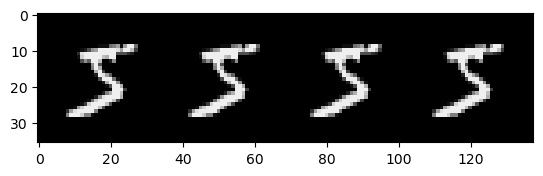

z equal? False
x equal? True


epoch: 1, loss: 5.030195e-09, norm: 5.470074e-10, param_norm: 9.328461e+02, vb_loss: -5.127211e-10, ce_loss: 3.715640e-06: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [01:34<00:00, 16.49it/s]


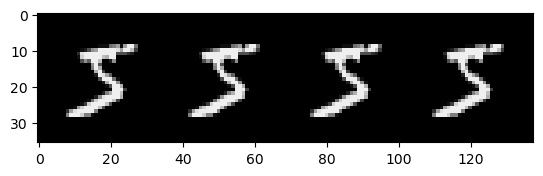

z equal? False
x equal? True


epoch: 2, loss: 1.494068e-09, norm: 6.847527e-12, param_norm: 9.273779e+02, vb_loss: 6.091735e-10, ce_loss: 1.640973e-06: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [01:34<00:00, 16.45it/s]


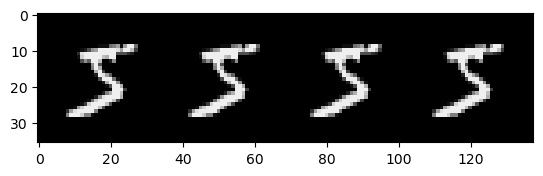

z equal? False
x equal? True


In [73]:
d3pm.train()

n_epoch = 3
for i in range(n_epoch):
    d3pm.train()
    pbar = tqdm(dataloader)
    loss_ema = None
    for x, _ in pbar:
        optim.zero_grad()
        x = x.to(device)
        x = (x * N).long().clamp(0, N - 1) # discritize x to 10 bins
        loss, info = d3pm(x)
        loss.backward()
        norm = torch.nn.utils.clip_grad_norm_(d3pm.x0_model.parameters(), 0.01)

        with torch.no_grad():
            param_norm = sum([torch.norm(p) for p in d3pm.x0_model.parameters()])
        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.99 * loss_ema + 0.01 * loss.item()
        pbar.set_description(f"epoch: {i}, loss: {loss_ema:.6e}, norm: {norm:.6e}, param_norm: {param_norm:.6e}, vb_loss: {info['vb_loss']:.6e}, ce_loss: {info['ce_loss']:.6e}")
        optim.step()
        
    d3pm.eval()
    with torch.no_grad():
        x = d3pm.sample(torch.randint(0, N, (4, 1, 32, 32)).cuda())
        x_as_image = make_grid(x.float() / N, nrow=4)
        plt.figure()
        plt.imshow(x_as_image.permute(1, 2, 0).cpu().numpy())
        plt.show()
        z1 = torch.randint(0, N, (4,1,32,32), device=device)
        z2 = torch.randint(0, N, (4,1,32,32), device=device)
        print("z equal?", torch.equal(z1, z2))
    
        x1 = d3pm.sample(z1)
        x2 = d3pm.sample(z2)
        print("x equal?", torch.equal(x1, x2))
    d3pm.train()

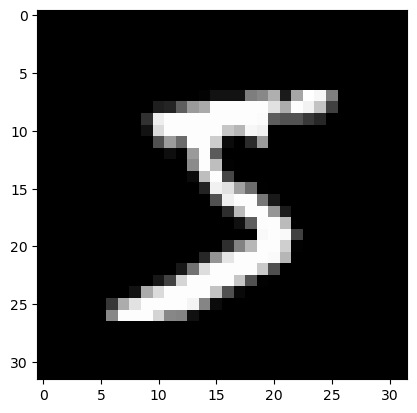

In [74]:
# visualize first dataset
x = next(iter(dataloader))[0][:1]
x_as_image = make_grid(x.float(), nrow=1)
plt.figure()
plt.imshow(x_as_image.permute(1, 2, 0).cpu().numpy())
plt.show()

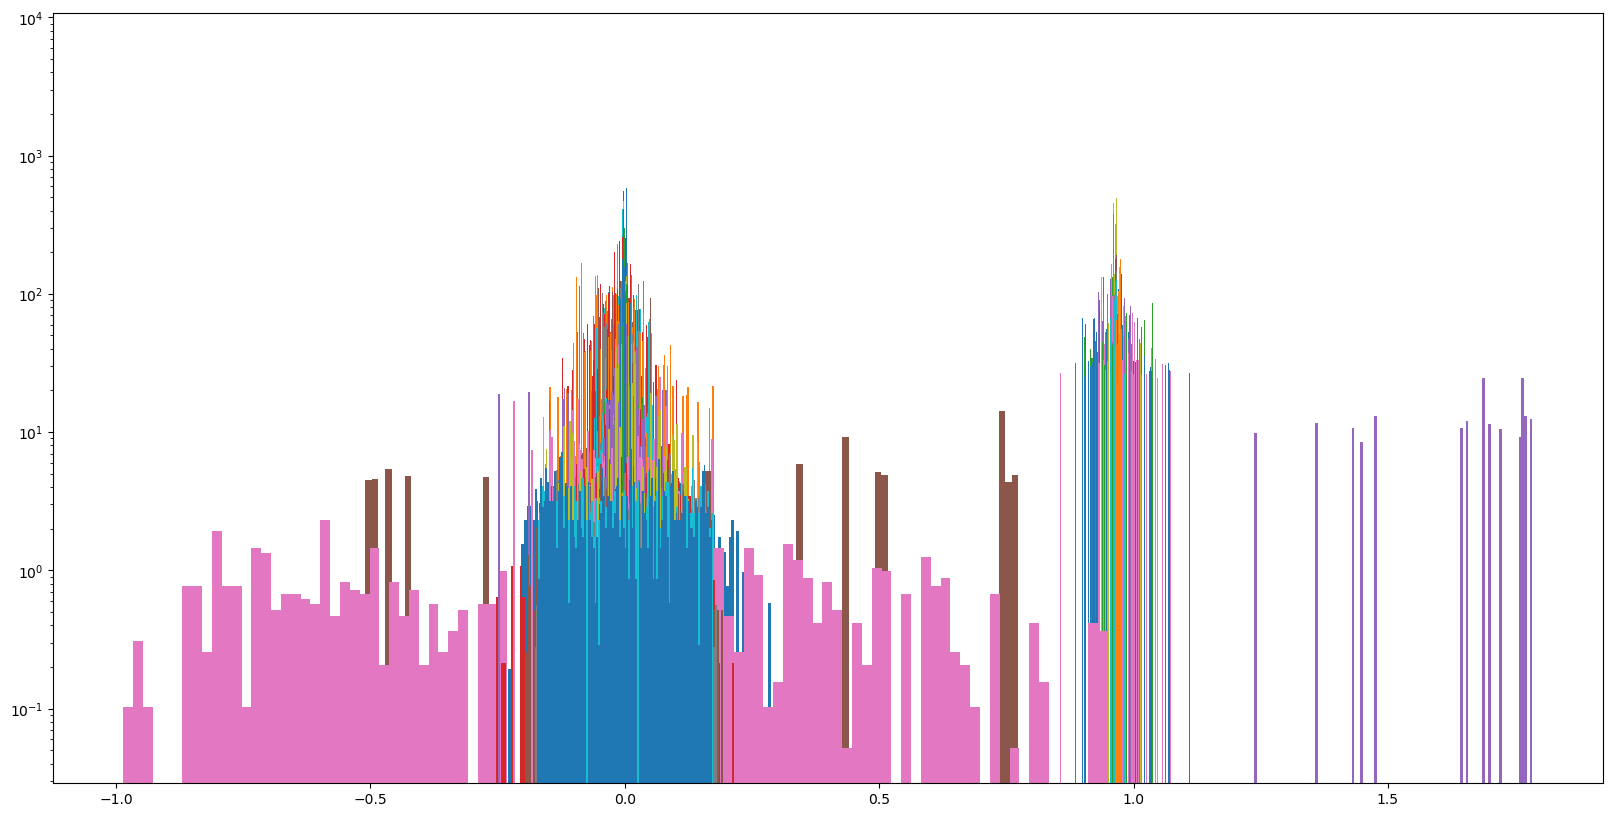

In [75]:
# check parameter distribution
from matplotlib import pyplot as plt
import numpy as np
def plot_param_dist(model):
    plot_dist = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            plot_dist[name] = param.detach().cpu().numpy().flatten()
            # sample 1000
            # replace nan with 1000
            plot_dist[name] = np.where(np.isnan(plot_dist[name]), 10, plot_dist[name])
            plot_dist[name] = np.random.choice(plot_dist[name], 1000)
    
    plt.figure(figsize=(20, 10))

    for idx, (name, dist) in enumerate(plot_dist.items()):
        plt.hist(dist, bins=100, density=True)
        
    # log y
    plt.yscale('log')
    #plt.legend()
    plt.show()

plot_param_dist(d3pm.x0_model)

tensor([[0.8116, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126],
        [0.0126, 0.8116, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126],
        [0.0126, 0.0126, 0.8116, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126],
        [0.0126, 0.0126, 0.0126, 0.8116, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126],
        [0.0126, 0.0126, 0.0126, 0.0126, 0.8116, 0.0126, 0.0126, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126],
        [0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.8116, 0.0126, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126],
        [0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.8116, 0.0126, 0.0126,
         0.0126, 0.0126, 0.0126, 0.01

<Axes: >

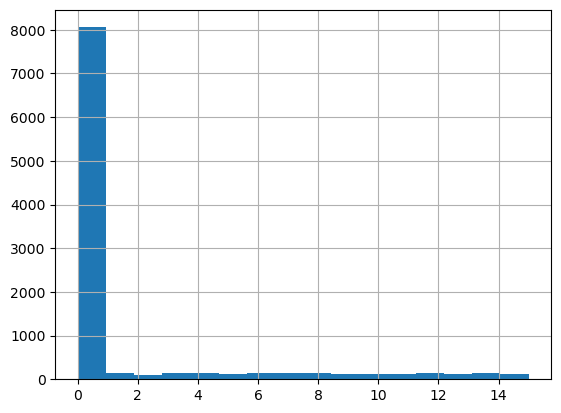

In [71]:
print(d3pm.q_mats[200])

# THIS CHECKS IF Q SAMPLE REALLY SAMPLES from Q.
x = torch.tensor([[0]])
collects = []
for idx in range(10000):
    sample = d3pm.q_sample(x, torch.tensor([200], device = 'cuda:0'), torch.rand((*x.shape, d3pm.num_classses), device='cuda:0'))
    collects.append(sample.item())

df = pd.DataFrame(collects, columns=['sample'])
df['sample'].hist(bins=16)

In [72]:
qmats = torch.arange(0, 1000).reshape(10, 10, 10)
image_as_pixels = torch.randint(0, 10, (1, 1, 1))
print(image_as_pixels)
qmats[image_as_pixels].shape

tensor([[[4]]])


torch.Size([1, 1, 1, 10, 10])